In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_path = r'\NYPD_Complaint_Data_Historic.csv'

In [3]:
chunk_size = 500000
chunks = []

In [4]:
dtype_dict = { 
    'ADDR_PCT_CD': 'float32',
    'KY_CD': 'int16',
    'PD_CD': 'float32',
    'CRM_ATPT_CPTD_CD': 'category',
    'LAW_CAT_CD': 'category',
    'BORO_NM': 'category',
    'JURIS_DESC': 'category',
    'PREM_TYP_DESC': 'category',
    'LOC_OF_OCCUR_DESC': 'category',
    'SUSP_AGE_GROUP': 'category',
    'SUSP_RACE': 'category',
    'SUSP_SEX': 'category',
    'VIC_AGE_GROUP': 'category',
    'VIC_RACE': 'category',
    'VIC_SEX': 'category',
    'Latitude': 'float32',
    'Longitude': 'float32',
}

# Read data in chunks
chunk_size = 500000
chunks = []

chunk_iterator = pd.read_csv(
    file_path,
    chunksize=chunk_size,
    dtype=dtype_dict,
    low_memory=False
)

print("file in chunks...")
for i, chunk in enumerate(chunk_iterator):
    chunks.append(chunk)
    print(f"  Processed chunk {i+1}")

# --- Combine all chunks into a single DataFrame ---
df = pd.concat(chunks, ignore_index=True)

print("\nData loading complete!")
print(f"Full dataset shape: {df.shape}")

file in chunks...
  Processed chunk 1
  Processed chunk 2
  Processed chunk 3
  Processed chunk 4
  Processed chunk 5
  Processed chunk 6
  Processed chunk 7
  Processed chunk 8
  Processed chunk 9
  Processed chunk 10
  Processed chunk 11
  Processed chunk 12
  Processed chunk 13
  Processed chunk 14
  Processed chunk 15
  Processed chunk 16
  Processed chunk 17
  Processed chunk 18
  Processed chunk 19

Data loading complete!
Full dataset shape: (9491946, 35)


In [5]:
df.head()

,CMPLNT_NUM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,ADDR_PCT_CD,RPT_DT,KY_CD,OFNS_DESC,PD_CD,...,SUSP_SEX,TRANSIT_DISTRICT,Latitude,Longitude,Lat_Lon,PATROL_BORO,STATION_NAME,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,39468181,02/20/2008,07:00:00,02/23/2008,08:00:00,88.0,02/23/2008,107,BURGLARY,221.0,...,(null),NaN,40.692463,-73.972710,"(40.692464, -73.972708)",PATROL BORO BKLYN NORTH,(null),25-44,WHITE,F
1,50539499,08/21/2008,22:00:00,08/21/2008,23:00:00,19.0,08/22/2008,109,GRAND LARCENY,438.0,...,(null),NaN,40.771339,-73.953415,"(40.771341, -73.953418)",PATROL BORO MAN NORTH,(null),45-64,WHITE HISPANIC,F
2,45223390,04/03/2008,03:35:00,04/03/2008,03:50:00,77.0,04/03/2008,106,FELONY ASSAULT,109.0,...,(null),NaN,40.671246,-73.926712,"(40.671245, -73.926713)",PATROL BORO BKLYN NORTH,(null),25-44,BLACK,F
3,50594658,08/19/2008,09:00:00,NaN,(null),32.0,08/27/2008,341,PETIT LARCENY,349.0,...,(null),NaN,40.813412,-73.943230,"(40.813412, -73.943226)",PATROL BORO MAN NORTH,(null),(null),UNKNOWN,M
4,44451016,03/10/2008,22:00:00,03/10/2008,22:10:00,67.0,03/11/2008,105,ROBBERY,397.0,...,M,NaN,40.650143,-73.944672,"(40.650142, -73.944674)",PATROL BORO BKLYN SOUTH,(null),25-44,BLACK,M


In [6]:
df.columns = df.columns.str.lower()
numeric_cmplnt_num = pd.to_numeric(df['cmplnt_num'], errors='coerce')
non_numeric_rows = df[numeric_cmplnt_num.isnull()]

print(f"\nFound {len(non_numeric_rows)} rows where 'cmplnt_num' is not a valid number.")

print("rows with non-numeric complaint numbers:")
print(non_numeric_rows[['cmplnt_num', 'ofns_desc', 'cmplnt_fr_dt']].head())


Found 7975 rows where 'cmplnt_num' is not a valid number.
rows with non-numeric complaint numbers:
            cmplnt_num                        ofns_desc cmplnt_fr_dt
302687  63975410H16535  MURDER & NON-NEGL. MANSLAUGHTER   07/22/2009
302704  63256138H16352  MURDER & NON-NEGL. MANSLAUGHTER   06/30/2009
302716  61400094H15961  MURDER & NON-NEGL. MANSLAUGHTER   05/03/2009
302722  69373208H17529  MURDER & NON-NEGL. MANSLAUGHTER   12/29/2009
302853  62074233H16082  MURDER & NON-NEGL. MANSLAUGHTER   05/24/2009



 Q1: What are the most common offenses?
ofns_desc
PETIT LARCENY                     1666745
HARRASSMENT 2                     1272980
ASSAULT 3 & RELATED OFFENSES       998322
CRIMINAL MISCHIEF & RELATED OF     916268
GRAND LARCENY                      831964
DANGEROUS DRUGS                    471830
OFF. AGNST PUB ORD SENSBLTY &      455183
FELONY ASSAULT                     393369
ROBBERY                            331515
BURGLARY                           310292
MISCELLANEOUS PENAL LAW            252602
DANGEROUS WEAPONS                  191024
GRAND LARCENY OF MOTOR VEHICLE     188235
OFFENSES AGAINST PUBLIC ADMINI     165397
VEHICLE AND TRAFFIC LAWS           161066
SEX CRIMES                         121949
INTOXICATED & IMPAIRED DRIVING     108457
FORGERY                             95672
CRIMINAL TRESPASS                   92306
THEFT-FRAUD                         90503
Name: count, dtype: int64


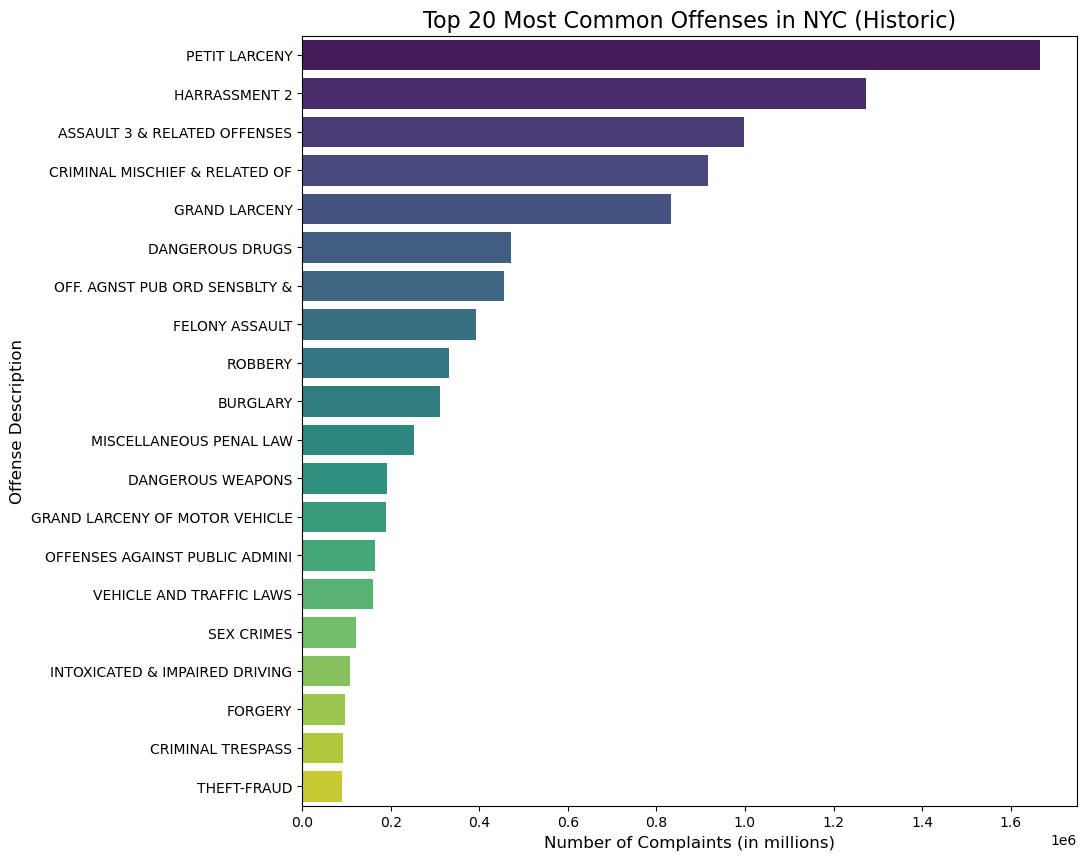

In [7]:
print("\n Q1: What are the most common offenses?")

top_20_offenses = df['ofns_desc'].value_counts().head(20)

print(top_20_offenses)

# --- Visualization ---
plt.figure(figsize=(10, 10))
sns.barplot(y=top_20_offenses.index, x=top_20_offenses.values, palette='viridis', hue= top_20_offenses.index, legend =False)
plt.title('Top 20 Most Common Offenses in NYC (Historic)', fontsize=16)
plt.xlabel('Number of Complaints (in millions)', fontsize=12)
plt.ylabel('Offense Description', fontsize=12)
plt.show()


 Q2: Crime breakdown by severity
law_cat_cd
MISDEMEANOR    5216195
FELONY         2981291
VIOLATION      1294460
Name: count, dtype: int64


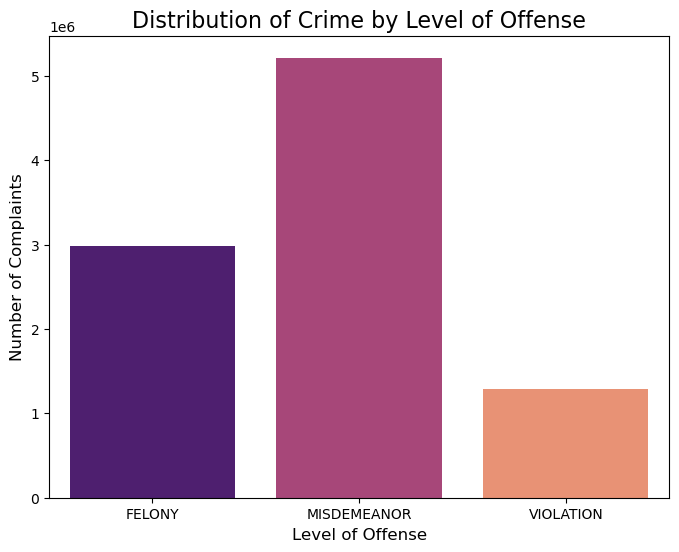

In [8]:
print("\n Q2: Crime breakdown by severity")
crime_levels = df['law_cat_cd'].value_counts()
print(crime_levels)

# --- Visualization ---
plt.figure(figsize=(8, 6))
sns.barplot(x=crime_levels.index, y=crime_levels.values, palette='magma', hue= crime_levels.index, legend = False)
plt.title('Distribution of Crime by Level of Offense', fontsize=16)
plt.xlabel('Level of Offense', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.show()


 Q3: Which borough has the most Felonies? 
Felonies by Borough:
boro_nm
BROOKLYN         911040
MANHATTAN        735148
QUEENS           640071
BRONX            592610
STATEN ISLAND    100731
(null)             1691
Name: count, dtype: int64


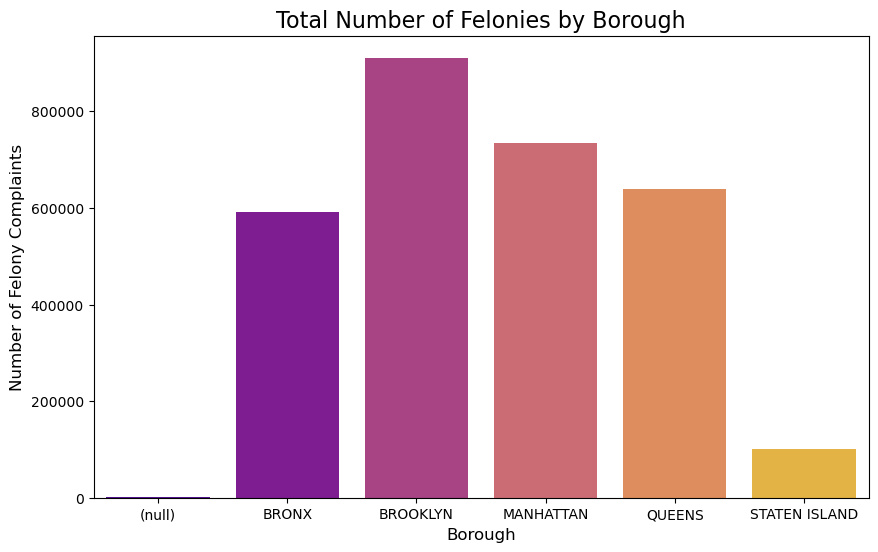

In [9]:
print("\n Q3: Which borough has the most Felonies? ")


felonies_df = df[df['law_cat_cd'] == 'FELONY']
felony_by_boro = felonies_df['boro_nm'].value_counts()
print("Felonies by Borough:")
print(felony_by_boro)

felony_by_boro_query = df.query("law_cat_cd == 'FELONY'")['boro_nm'].value_counts()

# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(x=felony_by_boro.index, y=felony_by_boro.values, palette='plasma', hue = felony_by_boro.index, legend = False )
plt.title('Total Number of Felonies by Borough', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of Felony Complaints', fontsize=12)
plt.show()

In [10]:

print("\n--- CREATING THE DATETIME COLUMN ---")

df.columns = df.columns.str.lower()


df['cmplnt_fr_datetime'] = pd.to_datetime(
    df['cmplnt_fr_dt'] + ' ' + df['cmplnt_fr_tm'],
    errors='coerce'
)


print("\n--- First 5 rows of the new column ---")
print(df['cmplnt_fr_datetime'].head())

print("\n--- Data type of the new column ---")
print(df['cmplnt_fr_datetime'].dtype) 


--- CREATING THE DATETIME COLUMN ---

--- First 5 rows of the new column ---
0   2008-02-20 07:00:00
1   2008-08-21 22:00:00
2   2008-04-03 03:35:00
3   2008-08-19 09:00:00
4   2008-03-10 22:00:00
Name: cmplnt_fr_datetime, dtype: datetime64[ns]

--- Data type of the new column ---
datetime64[ns]



 Q4: Top 5 Felonies in Brooklyn 
ofns_desc
GRAND LARCENY              216087
FELONY ASSAULT             123451
ROBBERY                    107071
BURGLARY                   102126
MISCELLANEOUS PENAL LAW     91670
Name: count, dtype: int64

 Count of each crime level within each borough 
law_cat_cd     FELONY  MISDEMEANOR  VIOLATION
boro_nm                                      
(null)           1691         6403        625
BRONX          592610      1176017     285554
BROOKLYN       911040      1479299     387441
MANHATTAN      735148      1291472     261492
QUEENS         640071      1014508     274294
STATEN ISLAND  100731       248496      85054


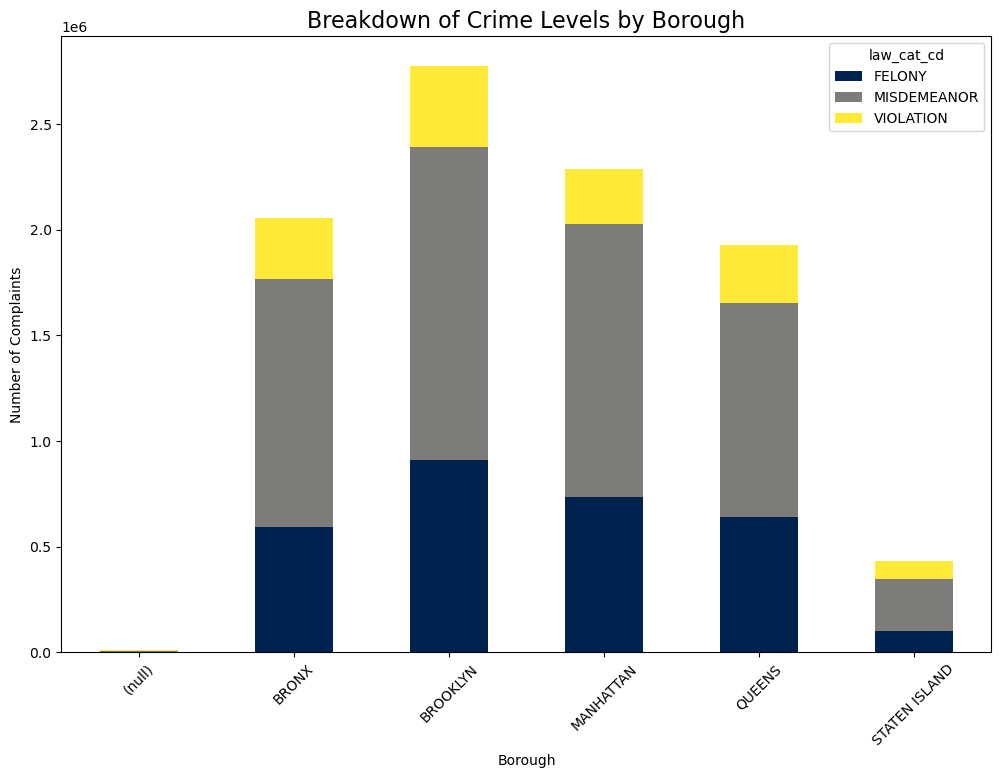

In [11]:
print("\n Q4: Top 5 Felonies in Brooklyn ")


brooklyn_top_felonies = df[
    (df['boro_nm'] == 'BROOKLYN') & (df['law_cat_cd'] == 'FELONY')
]['ofns_desc'].value_counts().head(5)

print(brooklyn_top_felonies)


print("\n Count of each crime level within each borough ")
crime_by_boro_level = df.groupby(['boro_nm', 'law_cat_cd'], observed =True).size().unstack(fill_value=0)
print(crime_by_boro_level)

# Visualize the groupby result
crime_by_boro_level.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='cividis')
plt.title('Breakdown of Crime Levels by Borough', fontsize=16)
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.show()


--- Q5: Yearly trend of complaints ---
Complaints counts by year:
year
1900.0         6
1905.0         2
1906.0         1
1908.0         3
1909.0         3
           ...  
2020.0    414074
2021.0    450073
2022.0    530834
2023.0    552442
2024.0    565118
Name: count, Length: 104, dtype: int64


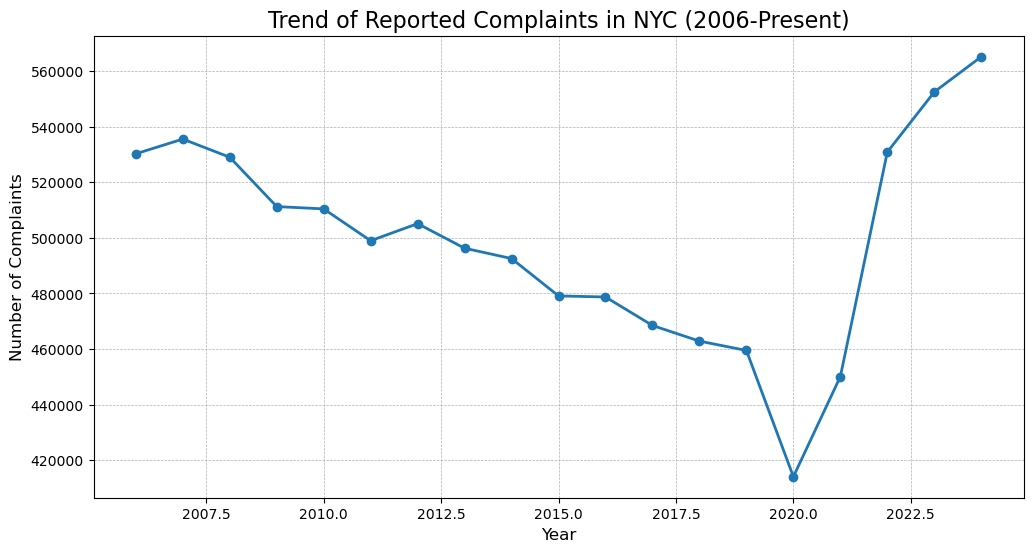

In [12]:
print("\n--- Q5: Yearly trend of complaints ---")

# Using dt.year to get year from datetime column
df['year'] = df['cmplnt_fr_datetime'].dt.year


print("Complaints counts by year:")
print(df['year'].value_counts().sort_index())


reasonable_years_df = df[df['year'] >= 2006]# The dataset is most complete from 2006 onwards.
yearly_counts = reasonable_years_df['year'].value_counts().sort_index()


# --- Visualization ---
plt.figure(figsize=(12, 6))
yearly_counts.plot(kind='line', marker='o', lw=2)
plt.title('Trend of Reported Complaints in NYC (2006-Present)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


--- Q6: What is the busiest hour for complaints? ---


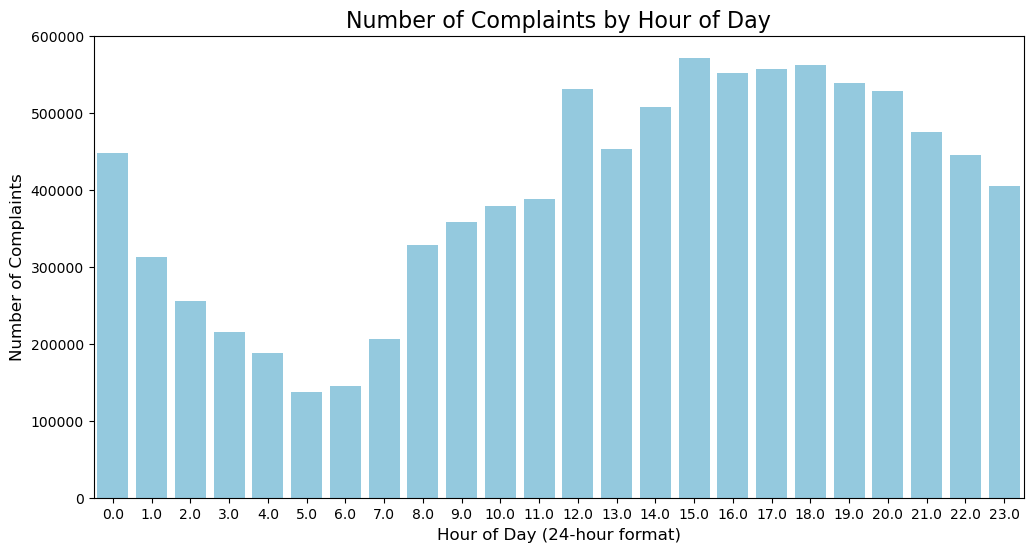

In [13]:
print("\n--- Q6: What is the busiest hour for complaints? ---")
df['hour'] = df['cmplnt_fr_datetime'].dt.hour
hourly_counts = df['hour'].value_counts().sort_index()

# --- Visualization ---
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='skyblue')
plt.title('Number of Complaints by Hour of Day', fontsize=16)
plt.xlabel('Hour of Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.show()

In [14]:
print("\n--- Q7: Analyzing Missing Data ---")
missing_values = df[['vic_age_group', 'vic_sex', 'vic_race', 'susp_age_group', 'susp_sex', 'susp_race']].isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

print("Percentage of Missing Data:")
print(missing_percentage)


--- Q7: Analyzing Missing Data ---
Percentage of Missing Data:
vic_age_group     0.0
vic_sex           0.0
vic_race          0.0
susp_age_group    0.0
susp_sex          0.0
susp_race         0.0
dtype: float64


In [15]:
print("\n--- Q8: Finding 'WEAPON' related crimes ---")

weapon_crimes = df[df['ofns_desc'].str.contains('WEAPON', na=False)]
weapon_crime_counts = weapon_crimes['ofns_desc'].value_counts()

print(weapon_crime_counts)


--- Q8: Finding 'WEAPON' related crimes ---
ofns_desc
DANGEROUS WEAPONS    191024
Name: count, dtype: int64


In [16]:
print("\n--- Q9: Creating a 'Time of Day' feature using .apply() ---")

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Let's see the result
print(df[['hour', 'time_of_day']].head(10))

# crimes by category
time_of_day_counts = df['time_of_day'].value_counts()
print("\nCrime counts by new 'Time of Day' category:")
print(time_of_day_counts)


--- Q9: Creating a 'Time of Day' feature using .apply() ---
   hour time_of_day
0   7.0     Morning
1  22.0       Night
2   3.0       Night
3   9.0     Morning
4  22.0       Night
5   1.0       Night
6   6.0     Morning
7   2.0       Night
8  15.0   Afternoon
9  19.0     Evening

Crime counts by new 'Time of Day' category:
time_of_day
Night        2746766
Afternoon    2617208
Evening      2186236
Morning      1941736
Name: count, dtype: int64


In [17]:
print(list(df.columns))

['cmplnt_num', 'cmplnt_fr_dt', 'cmplnt_fr_tm', 'cmplnt_to_dt', 'cmplnt_to_tm', 'addr_pct_cd', 'rpt_dt', 'ky_cd', 'ofns_desc', 'pd_cd', 'pd_desc', 'crm_atpt_cptd_cd', 'law_cat_cd', 'boro_nm', 'loc_of_occur_desc', 'prem_typ_desc', 'juris_desc', 'jurisdiction_code', 'parks_nm', 'hadevelopt', 'housing_psa', 'x_coord_cd', 'y_coord_cd', 'susp_age_group', 'susp_race', 'susp_sex', 'transit_district', 'latitude', 'longitude', 'lat_lon', 'patrol_boro', 'station_name', 'vic_age_group', 'vic_race', 'vic_sex', 'cmplnt_fr_datetime', 'year', 'hour', 'time_of_day']



Q10:: top 10 most common complaint premises
Top 10 most common complaints premises:
prem_typ_desc
STREET                        2965814
RESIDENCE - APT. HOUSE        2027818
RESIDENCE-HOUSE                920813
RESIDENCE - PUBLIC HOUSING     690360
CHAIN STORE                    276664
OTHER                          245868
COMMERCIAL BUILDING            237060
TRANSIT - NYC SUBWAY           220528
DEPARTMENT STORE               199292
GROCERY/BODEGA                 125802
Name: count, dtype: int64


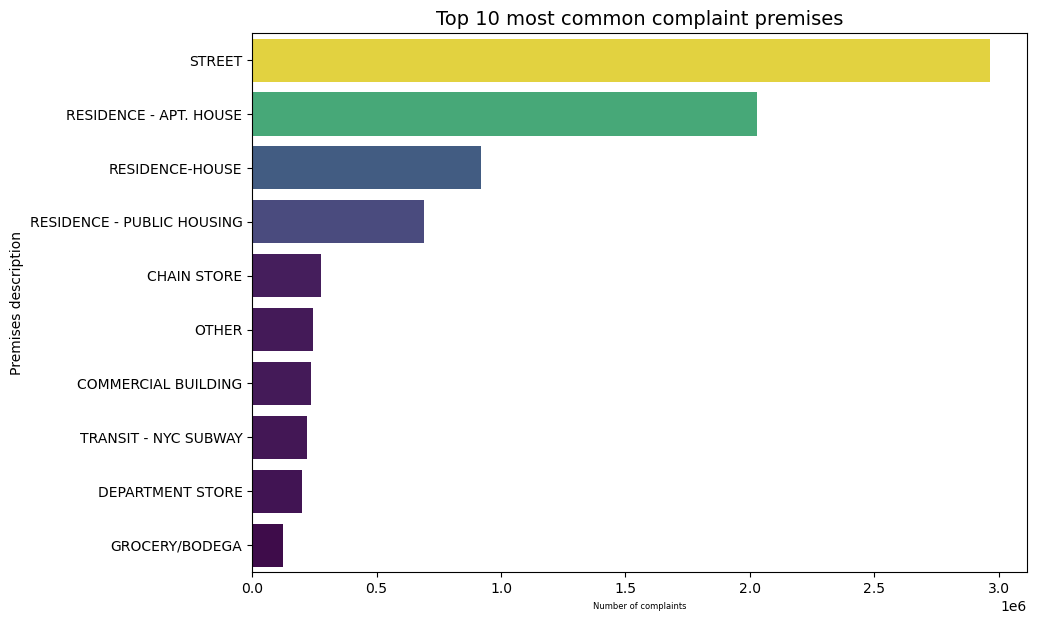

In [18]:
print("\nQ10:: top 10 most common complaint premises")


top_10_premises = df['prem_typ_desc'].value_counts().head(10)
print("Top 10 most common complaints premises:")
print(top_10_premises)

#----Visualization---

plt.figure(figsize = (10,7))
sns.barplot(x=top_10_premises.values , y= top_10_premises.index, palette = 'viridis', hue = top_10_premises, legend = False)
plt.title("Top 10 most common complaint premises", fontsize = 14)
plt.xlabel("Number of complaints", fontsize = 6)
plt.ylabel("Premises description", fontsize = 10)


plt.show()

In [19]:
print("\n Q: Most common crime at #1 premises")

top_premise = top_10_premises.index[0]
print(f"\n The #1 most common crime premise is: '{top_premise}'")


top_premise_df = df[df['prem_typ_desc'] == top_premise]


top_crime_at_top_premise = top_premise_df['ofns_desc'].value_counts().head(5)

print(f"\nTop 5 crime occuring at '{top_premise}':")
print(top_crime_at_top_premise)




 Q: Most common crime at #1 premises

 The #1 most common crime premise is: 'STREET'

Top 5 crime occuring at 'STREET':
ofns_desc
PETIT LARCENY                     436837
CRIMINAL MISCHIEF & RELATED OF    380458
DANGEROUS DRUGS                   280424
ASSAULT 3 & RELATED OFFENSES      276673
HARRASSMENT 2                     236042
Name: count, dtype: int64


In [20]:
print("\nQ11: Victim age groups vs crime levels")


valid_age_group = ['<18', '18-24', '25-44', '45-64', '65+']
analysis_df = df[df['vic_age_group'].isin(valid_age_group)]

victim_pivot_table = pd.pivot_table(
    analysis_df,
    index = "vic_age_group",
    columns = "law_cat_cd",
    values = "cmplnt_num",
    aggfunc = "count",
    observed = True
)

victim_pivot_table = victim_pivot_table.reindex(valid_age_group)

print("Pivot Table: Victim Age vs. Crime Level (Count of Complaints)")

print(victim_pivot_table)





Q11: Victim age groups vs crime levels
Pivot Table: Victim Age vs. Crime Level (Count of Complaints)
law_cat_cd      FELONY  MISDEMEANOR  VIOLATION
vic_age_group                                 
<18             135578       219371      84621
18-24           323843       476061     148631
25-44          1026280      1567925     572614
45-64           518017       781439     340386
65+             148429       140871      67082



Same data, but as row-wise percentages:
law_cat_cd     FELONY  MISDEMEANOR  VIOLATION
vic_age_group                                
<18             30.84        49.91      19.25
18-24           34.14        50.19      15.67
25-44           32.41        49.51      18.08
45-64           31.59        47.65      20.76
65+             41.65        39.53      18.82


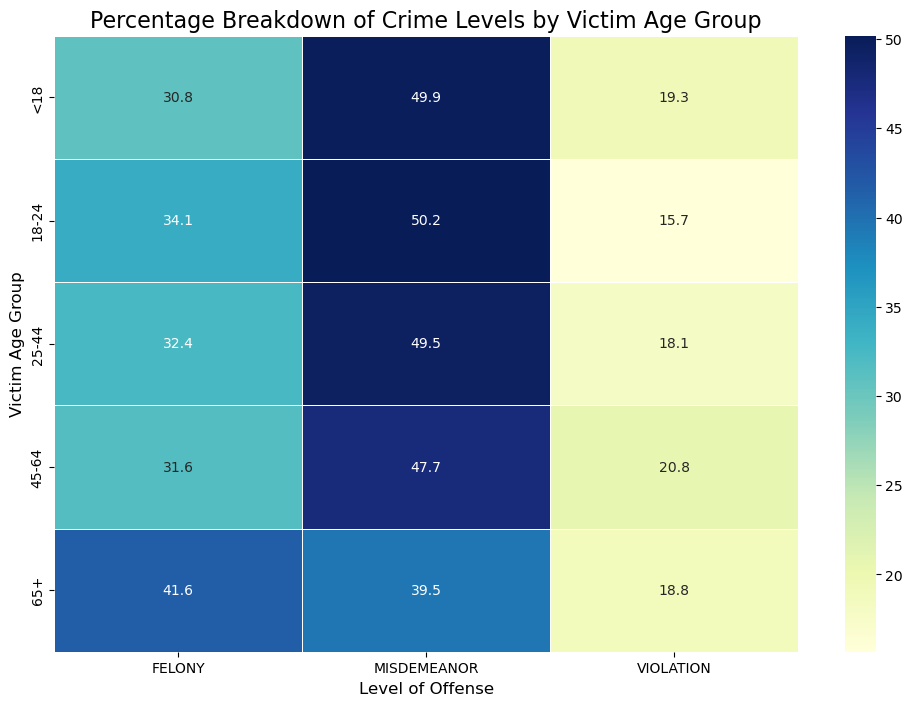

In [21]:
victim_pivot_normalized = victim_pivot_table.div(victim_pivot_table.sum(axis=1), axis=0) * 100

print("\nSame data, but as row-wise percentages:")
print(victim_pivot_normalized.round(2))

# Visualize data with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    victim_pivot_normalized,
    annot=True,          
    fmt='.1f',           
    cmap='YlGnBu',       
    linewidths=.5
)
plt.title('Percentage Breakdown of Crime Levels by Victim Age Group', fontsize=16)
plt.xlabel('Level of Offense', fontsize=12)
plt.ylabel('Victim Age Group', fontsize=12)
plt.show()


 Q12. Seasonal and weekly crime patterns
month
1     40412.210526
2     35858.105263
3     40694.736842
4     39818.578947
5     43392.631579
6     42970.315789
7     44523.473684
8     44461.263158
9     42815.263158
10    43867.789474
11    40292.473684
12    39328.210526
dtype: float64


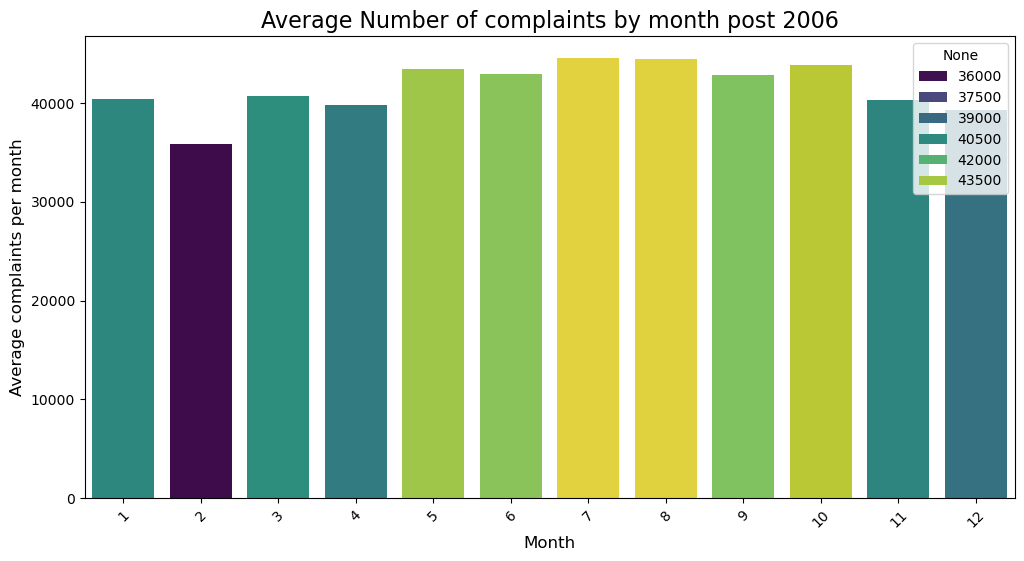

In [22]:
print("\n Q12. Seasonal and weekly crime patterns")

# -----------  Monthly pattern   ------------------

reasonable_year_df = df[df['cmplnt_fr_datetime'].dt.year >= 2006].copy()

reasonable_year_df['month'] = reasonable_year_df['cmplnt_fr_datetime'].dt.month
monthly_avg = reasonable_year_df.groupby('month').size()/len(reasonable_years_df['cmplnt_fr_datetime'].dt.year.unique())

print(monthly_avg)

plt.figure(figsize = (12,6))
# monthly_avg.plot(kind = 'bar', color = 'teal') # we can use this when our data is already grouped/aggregated and we want quick and simple plots
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette="viridis", hue = monthly_avg)
plt.title("Average Number of complaints by month post 2006", fontsize = 16)
plt.xlabel("Month", fontsize = 12)
plt.ylabel("Average complaints per month", fontsize = 12)
plt.xticks(ticks = range(12), label = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep','Oct', 'Nov', 'Dec'], rotation = 45)
plt.show()


 Total complaints by day of the week
day_of_week
Monday       1292419
Tuesday      1359041
Wednesday    1395863
Thursday     1374384
Friday       1454175
Saturday     1355445
Sunday       1238939
Name: count, dtype: int64


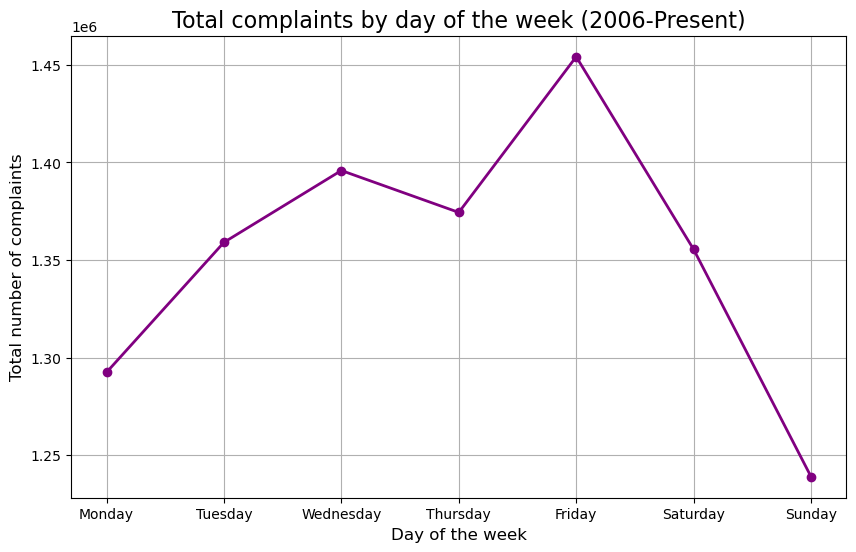

In [23]:
# ------ Day of the week pattern ----------

reasonable_year_df['day_of_week'] = reasonable_year_df['cmplnt_fr_datetime'].dt.day_name()
weekly_counts = reasonable_year_df['day_of_week'].value_counts()


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_counts = weekly_counts.reindex(day_order)

print('\n Total complaints by day of the week')
print(weekly_counts)

plt.figure(figsize = (10,6))
weekly_counts.plot(kind = 'line', marker = 'o', color = 'purple', lw=2)
plt.title("Total complaints by day of the week (2006-Present)", fontsize = 16)
plt.xlabel("Day of the week", fontsize = 12)
plt.ylabel("Total number of complaints", fontsize = 12)
plt.grid(True)
plt.show()


 Q13. Case study on burglary pattern


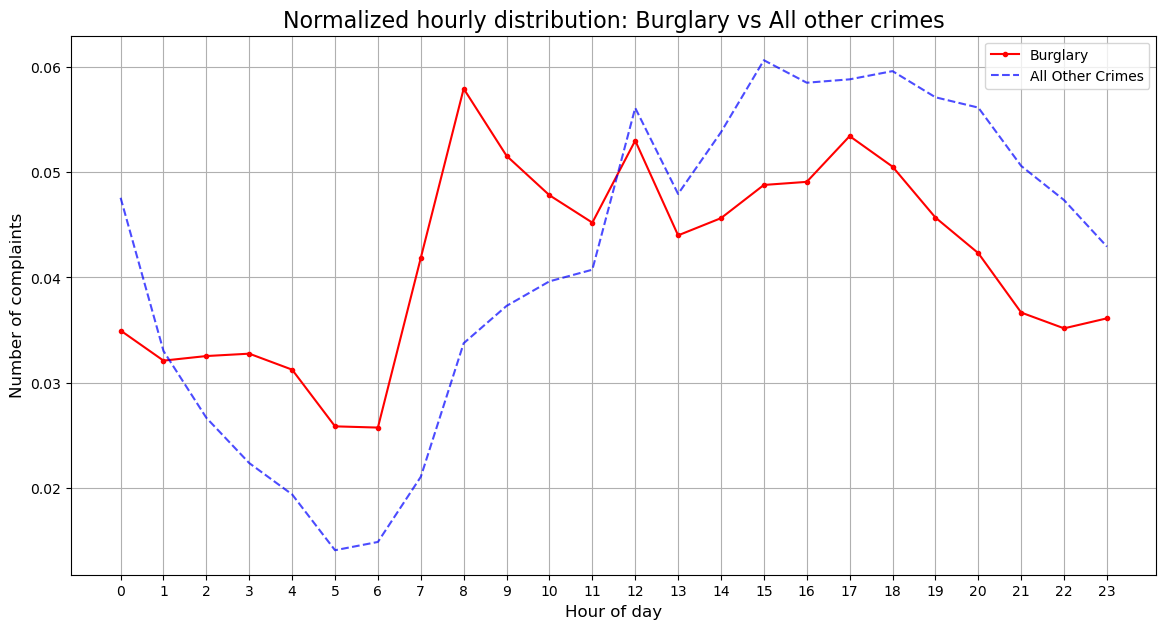

In [24]:
print("\n Q13. Case study on burglary pattern")

# Creating two dataframes one for burglary and another for rest of the crimes
burglary_df = df[df['ofns_desc'].str.lower() == 'burglary'].copy()
other_crimes = df[df['ofns_desc'].str.lower() != 'burglary'].copy()


# ---------- Times of day comparison -----------
burglary_hourly = burglary_df['hour'].value_counts(normalize = True).sort_index()
other_hourly = other_crimes['hour'].value_counts(normalize = True).sort_index()



plt.figure(figsize = (14,7))
burglary_hourly.plot(kind = 'line', label='Burglary', color='red',marker='.')
other_hourly.plot(kind='line',label='All Other Crimes', color='blue',linestyle='--',alpha=0.7)
plt.title('Normalized hourly distribution: Burglary vs All other crimes',fontsize= 16)
plt.xlabel('Hour of day', fontsize = 12)
plt.ylabel('Number of complaints', fontsize =12)
plt.legend()
plt.xticks(range(24))
plt.grid(True)
plt.show()

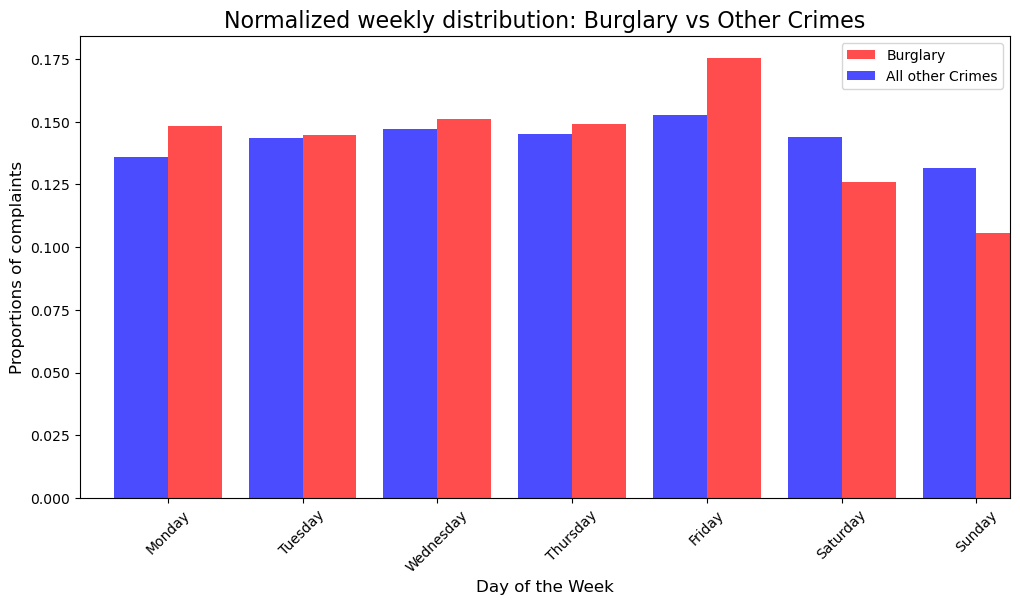

In [25]:
#-------------Day of week comparison-----

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
burglary_weekly = burglary_df['cmplnt_fr_datetime'].dt.day_name().value_counts(normalize=True).reindex(day_order)
other_weekly = other_crimes['cmplnt_fr_datetime'].dt.day_name().value_counts(normalize=True).reindex(day_order)

plt.figure(figsize=(12,6))
burglary_weekly.plot(kind='bar', label='Burglary',color='red',alpha=0.7,position=0,width=0.4)
other_weekly.plot(kind='bar',label='All other Crimes',color='Blue',alpha=0.7,position=1,width=0.4)
plt.title('Normalized weekly distribution: Burglary vs Other Crimes', fontsize=16)
plt.xlabel('Day of the Week',fontsize=12)
plt.ylabel('Proportions of complaints', fontsize=12)
plt.legend()
plt.xticks(rotation = 45)
plt.show()
